In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')


In [41]:
# ====================== MODEL DICTIONARY ======================
MODEL_INFO = {
    'VGG16': (VGG16, (224, 224), tf.keras.applications.vgg16.preprocess_input),
    'VGG19': (VGG19, (224, 224), tf.keras.applications.vgg19.preprocess_input),
    'ResNet50': (ResNet50, (224, 224), tf.keras.applications.resnet50.preprocess_input),
    'InceptionV3': (InceptionV3, (299, 299), tf.keras.applications.inception_v3.preprocess_input),
    'Xception': (Xception, (299, 299), tf.keras.applications.xception.preprocess_input),
    'MobileNetV2': (MobileNetV2, (224, 224), tf.keras.applications.mobilenet_v2.preprocess_input),
    'DenseNet121': (DenseNet121, (224, 224), tf.keras.applications.densenet.preprocess_input),
    'InceptionResNetV2': (InceptionResNetV2, (299, 299), tf.keras.applications.inception_resnet_v2.preprocess_input),
    'NASNetMobile': (NASNetMobile, (224, 224), tf.keras.applications.nasnet.preprocess_input),
    'EfficientNetB0': (EfficientNetB0, (224, 224), tf.keras.applications.efficientnet.preprocess_input),
}

In [42]:
def load_dataset(dataset_dir):
    image_paths, labels = [], []
    class_folders = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
    for class_id, folder in enumerate(class_folders):
        folder_path = os.path.join(dataset_dir, folder)
        for fname in sorted(os.listdir(folder_path)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, fname))
                labels.append(class_id)
    return image_paths, np.array(labels), len(class_folders)

In [ ]:
def classify_images(dataset_dir, dataset_name):
    image_paths, _, _ = load_dataset(dataset_dir)
    all_results = []   # This will collect data for CSV
    
    for model_name, (ModelClass, target_size, preprocess) in MODEL_INFO.items():
        print(f"Classifying {len(image_paths)} {dataset_name} images with {model_name}...")
        base_model = ModelClass(weights='imagenet', include_top=True)
        
        for path in image_paths:
            img = image.load_img(path, target_size=target_size)
            x = image.img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess(x)
            preds = base_model.predict(x, verbose=0)
            decoded = decode_predictions(preds, top=5)[0]
            
            # Top-1
            top1_class = decoded[0][1]
            top1_score = decoded[0][2] * 100
            
            # Top-5 as readable string
            top5_list = [f"{item[1]} ({item[2]*100:.1f}%)" for item in decoded]
            top5_str = " | ".join(top5_list)
            
            # Store for CSV
            all_results.append({
                'Image': os.path.basename(path),
                'Model': model_name,
                'Top1_Class': top1_class,
                'Top1_Confidence_%': round(top1_score, 2),
                'Top5_Predictions': top5_str
            })
        
        print(f"   → {model_name} done")
    
    # Convert to DataFrame and save as CSV
    df = pd.DataFrame(all_results)
    csv_path = f"../results/classifications/{dataset_name.lower()}_classifications.csv"
    df.to_csv(csv_path, index=False)
    
    print(f"{dataset_name} classification completed and saved to:\n   {csv_path}\n")
    return df   # Now returns the DataFrame instead of dict

In [44]:
def extract_features(model_name, image_paths):
    ModelClass, target_size, preprocess_input = MODEL_INFO[model_name]
    base_model = ModelClass(weights='imagenet', include_top=False)
    x = GlobalAveragePooling2D()(base_model.output)
    feature_extractor = Model(inputs=base_model.input, outputs=x)
    
    imgs = [image.img_to_array(image.load_img(p, target_size=target_size)) for p in image_paths]
    imgs = np.stack(imgs)
    preprocessed = preprocess_input(imgs)
    
    features = feature_extractor.predict(preprocessed, batch_size=16, verbose=1)
    print(f"   → Features extracted: {features.shape}")
    return features

In [45]:
def reduce_and_plot(features, labels, method, model_name, dataset_name):
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
    elif method == 't-SNE':
        reducer = TSNE(n_components=2, perplexity=5, random_state=42)
    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=2, random_state=42)
    
    reduced = reducer.fit_transform(features)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab10',
                    s=100, alpha=0.8, edgecolor='k')
    plt.title(f'{model_name} — {method} on {dataset_name}')
    plt.xlabel(f'{method} 1'); plt.ylabel(f'{method} 2')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save plot
    save_path = f"../results/plots/{model_name}_{method}_{dataset_name.lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"   → Plot saved: {save_path}")

Starting Assignment Pipeline...
Faces: 35 images, 7 people
Flowers: 25 images, 5 types

Classifying 35 Faces images with VGG16...
   → VGG16 done
Classifying 35 Faces images with VGG19...
   → VGG19 done
Classifying 35 Faces images with ResNet50...
   → ResNet50 done
Classifying 35 Faces images with InceptionV3...
   → InceptionV3 done
Classifying 35 Faces images with Xception...
   → Xception done
Classifying 35 Faces images with MobileNetV2...
   → MobileNetV2 done
Classifying 35 Faces images with DenseNet121...
   → DenseNet121 done
Classifying 35 Faces images with InceptionResNetV2...
   → InceptionResNetV2 done
Classifying 35 Faces images with NASNetMobile...
   → NASNetMobile done
Classifying 35 Faces images with EfficientNetB0...
   → EfficientNetB0 done
Faces classification completed and saved to:
   ../results/classifications/faces_classifications.csv

Classifying 25 Flowers images with VGG16...
   → VGG16 done
Classifying 25 Flowers images with VGG19...
   → VGG19 done
Classi

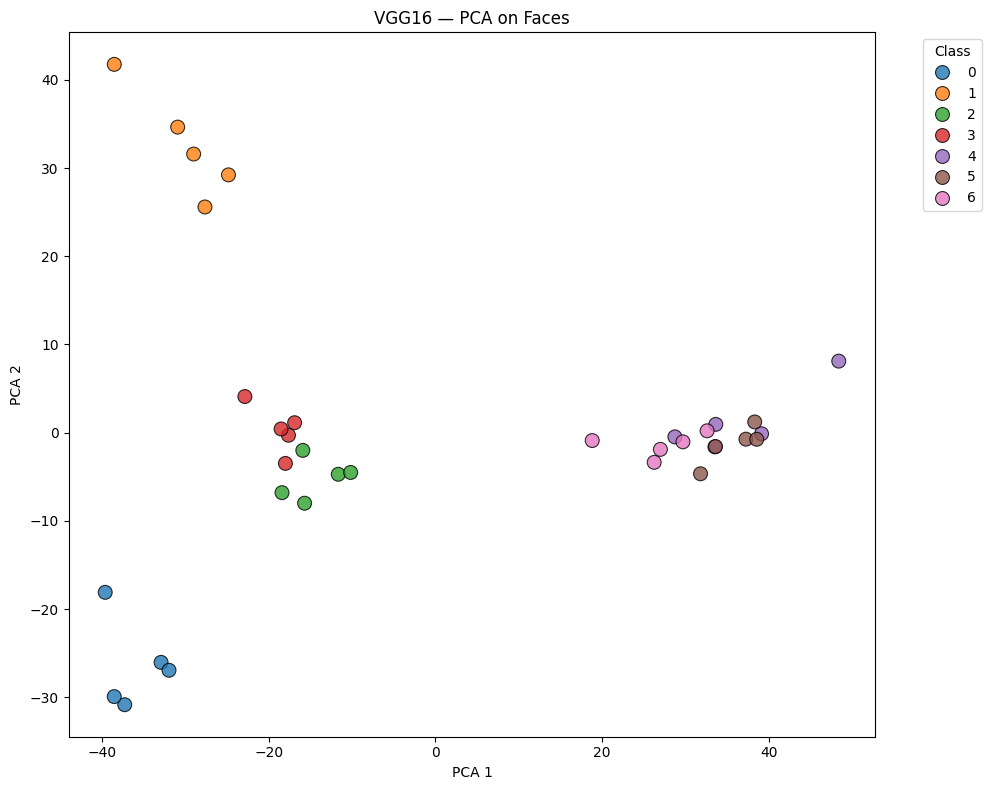

   → Plot saved: ../results/plots/VGG16_PCA_faces.png


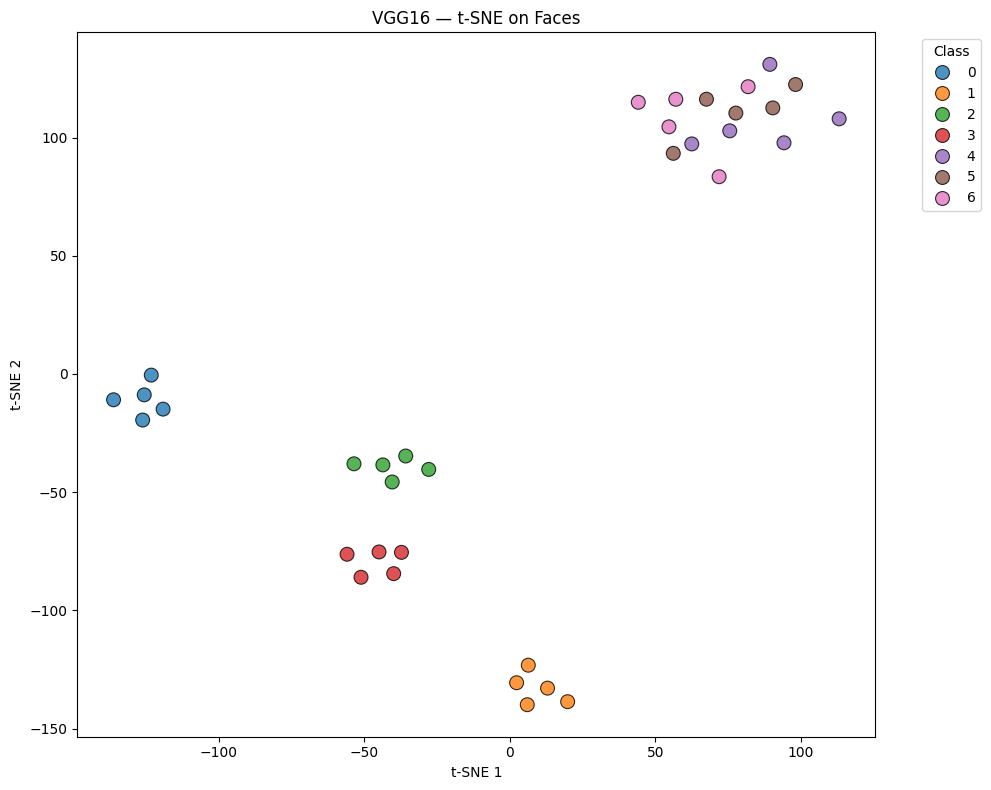

   → Plot saved: ../results/plots/VGG16_t-SNE_faces.png


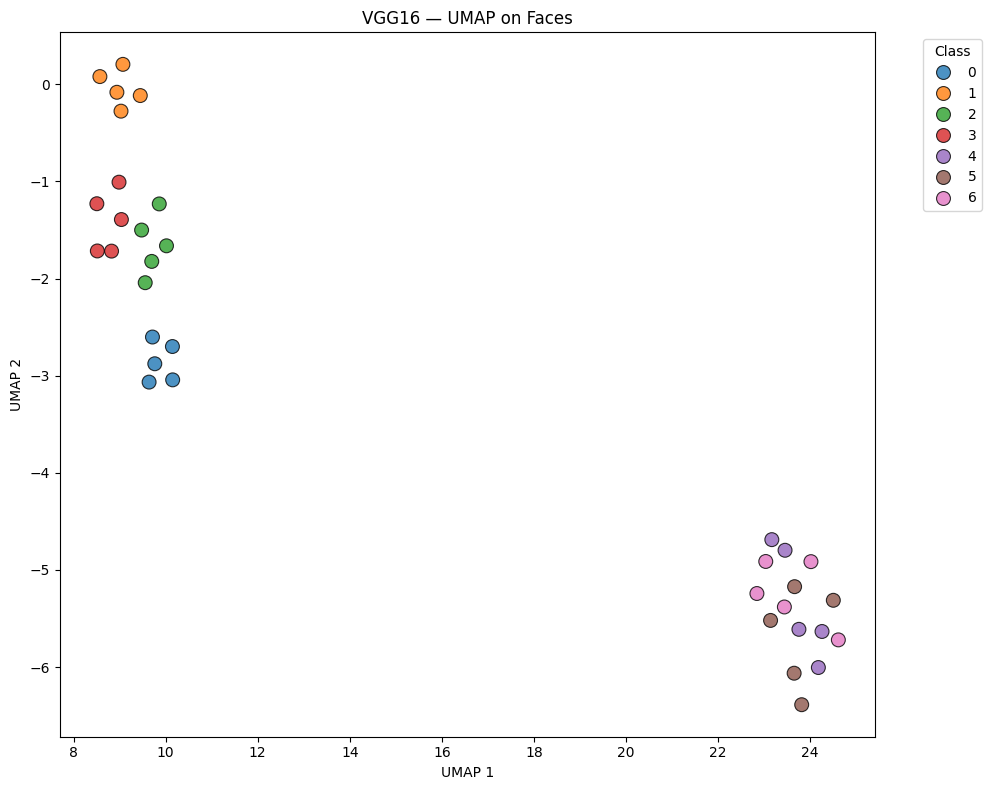

   → Plot saved: ../results/plots/VGG16_UMAP_faces.png
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
   → Features extracted: (25, 512)


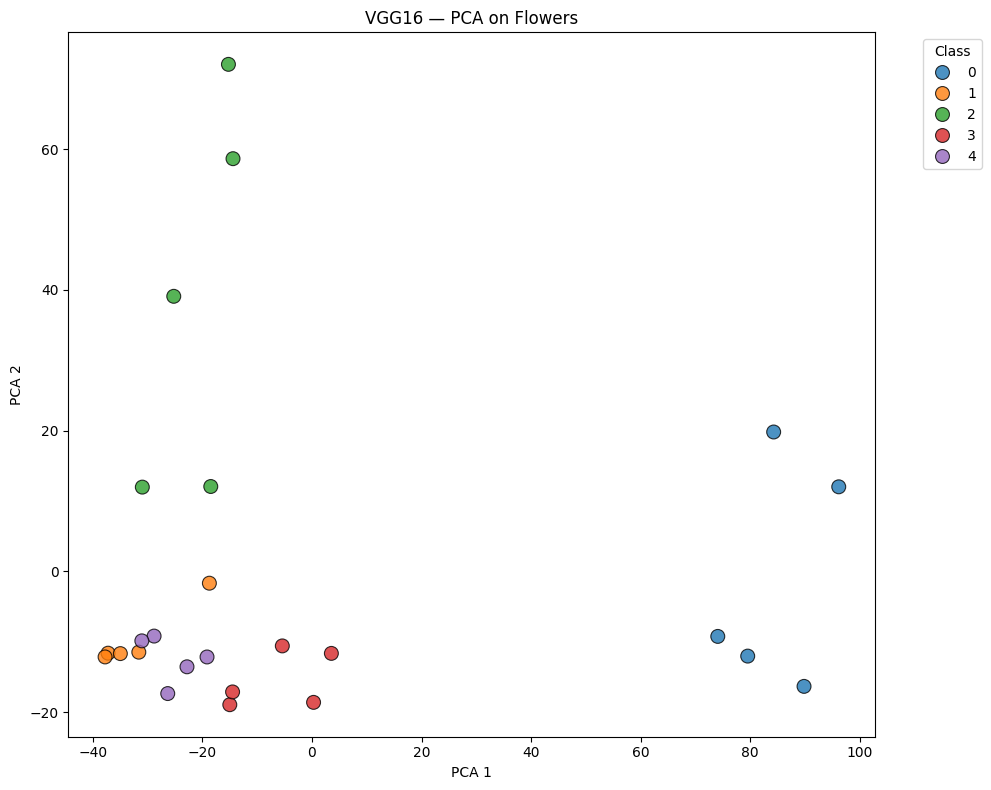

   → Plot saved: ../results/plots/VGG16_PCA_flowers.png


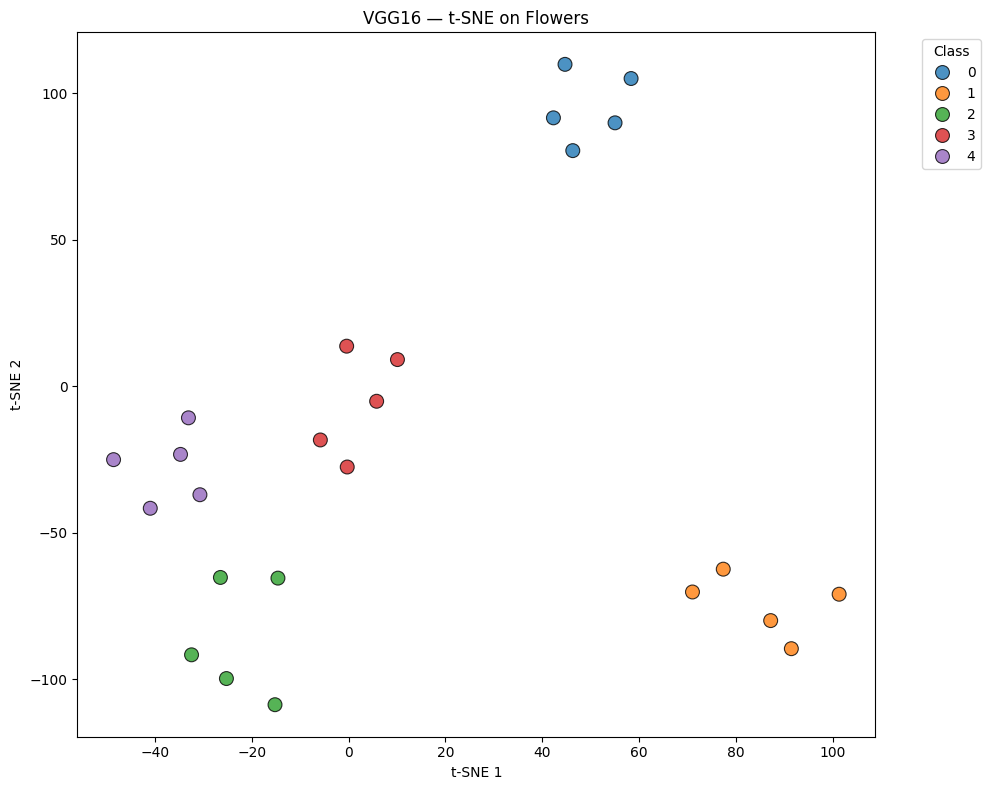

   → Plot saved: ../results/plots/VGG16_t-SNE_flowers.png


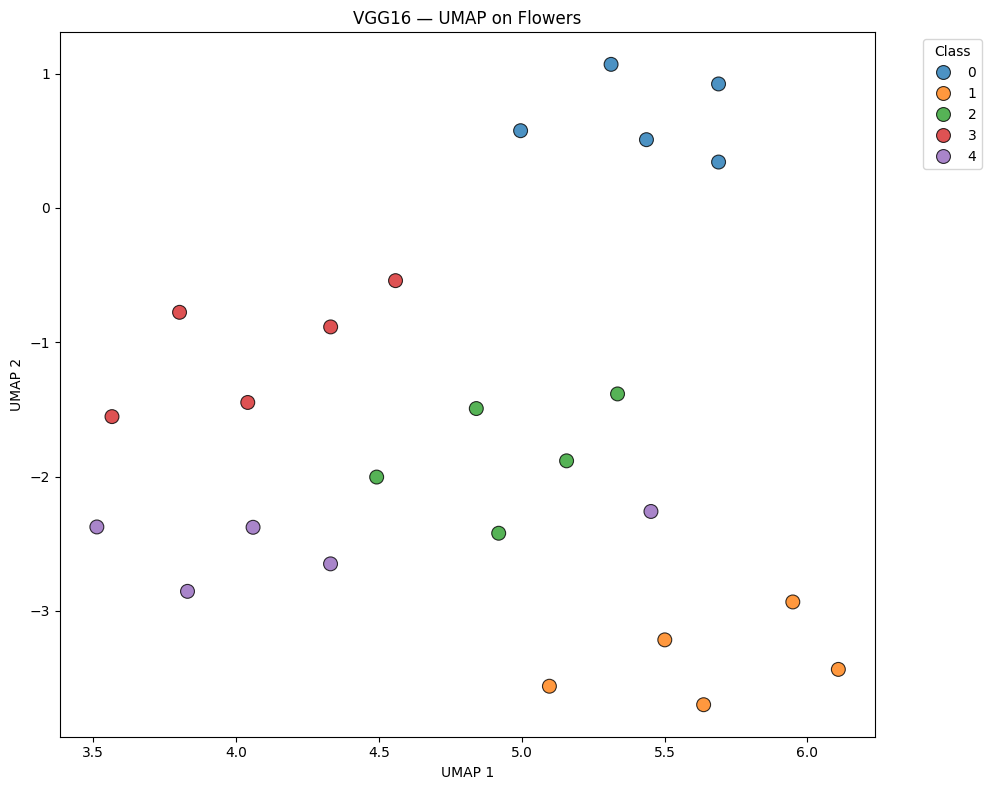

   → Plot saved: ../results/plots/VGG16_UMAP_flowers.png

Processing ResNet50...
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
   → Features extracted: (35, 2048)


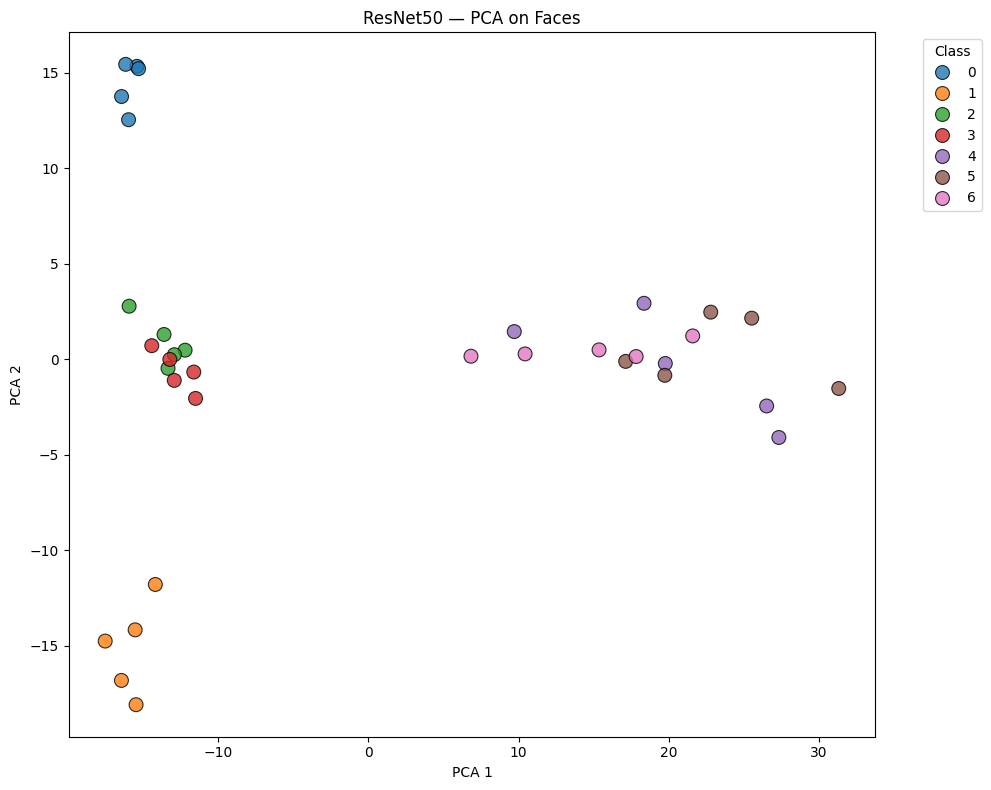

   → Plot saved: ../results/plots/ResNet50_PCA_faces.png


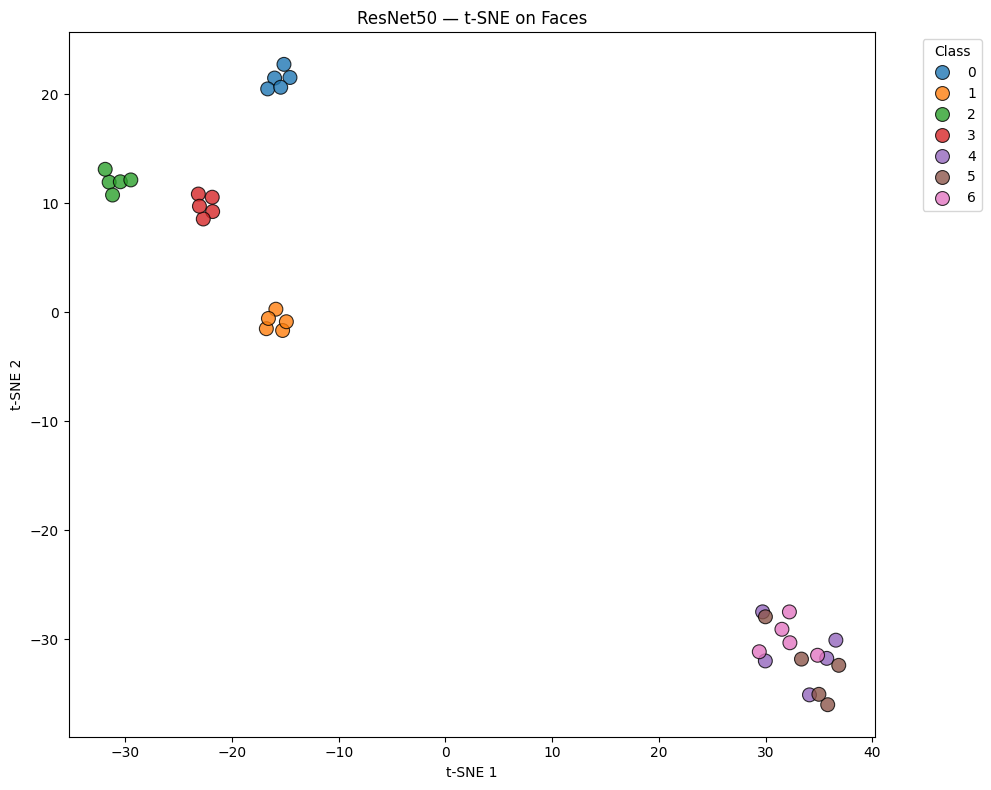

   → Plot saved: ../results/plots/ResNet50_t-SNE_faces.png


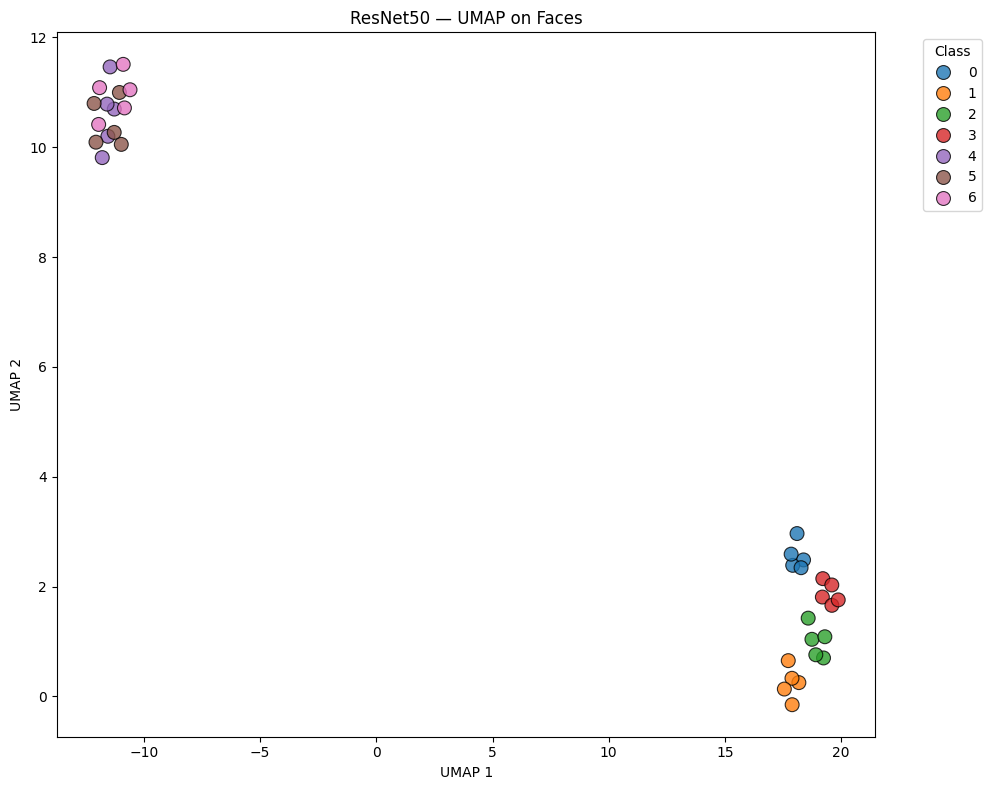

   → Plot saved: ../results/plots/ResNet50_UMAP_faces.png
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
   → Features extracted: (25, 2048)


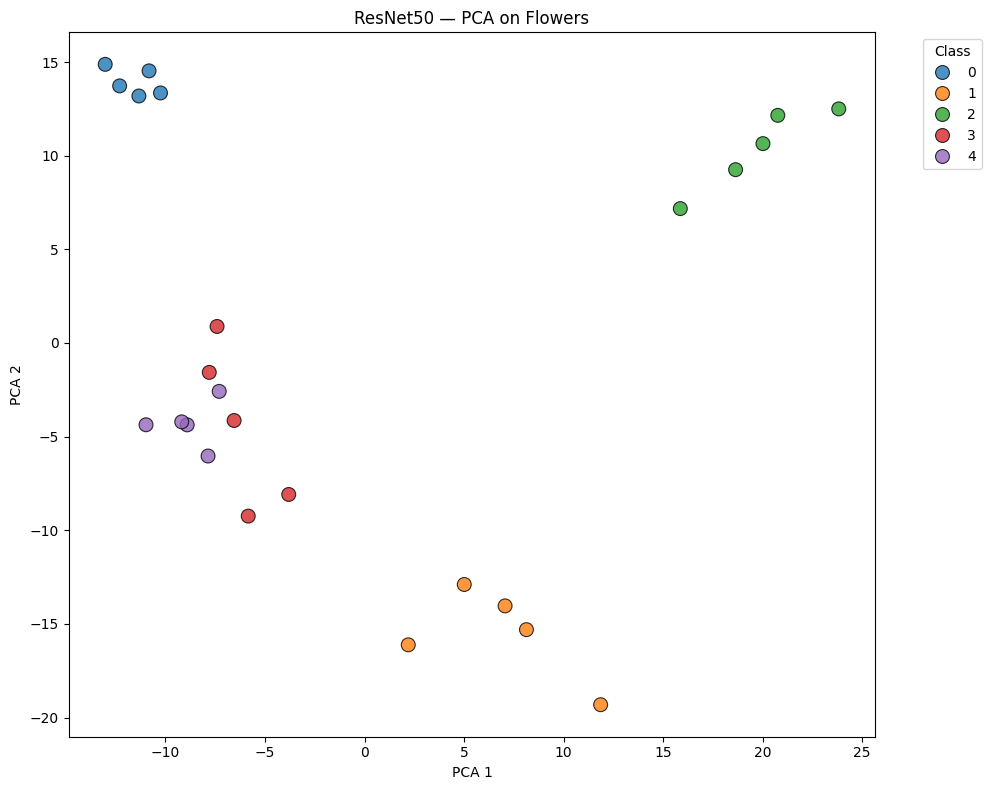

   → Plot saved: ../results/plots/ResNet50_PCA_flowers.png


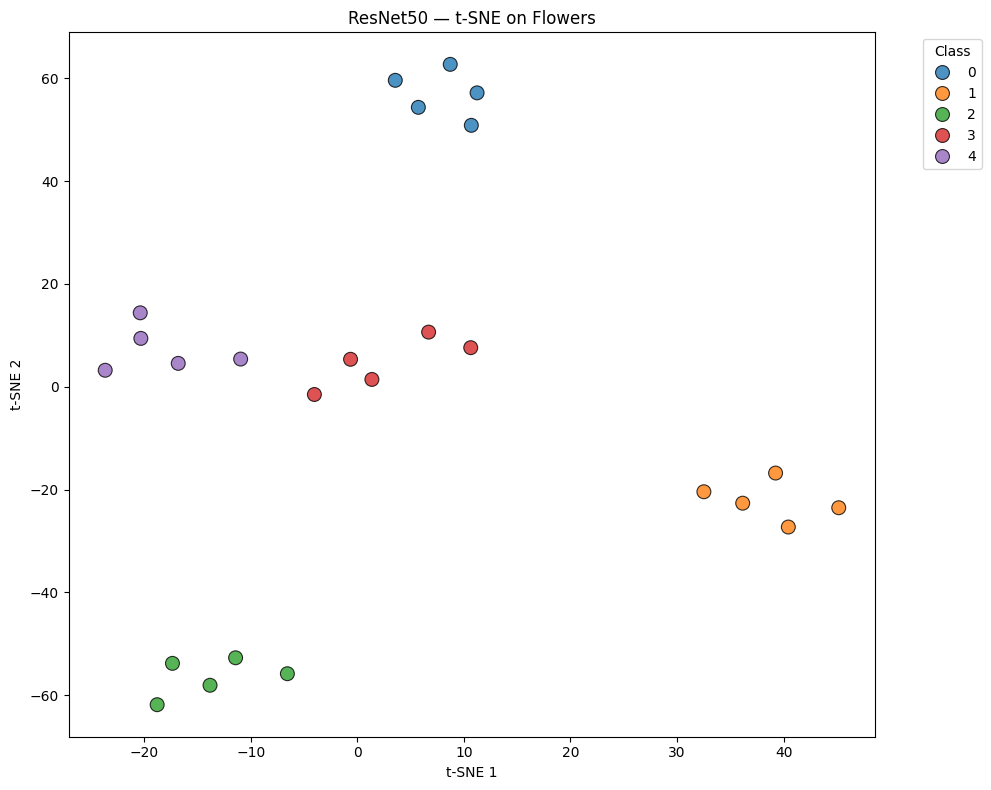

   → Plot saved: ../results/plots/ResNet50_t-SNE_flowers.png


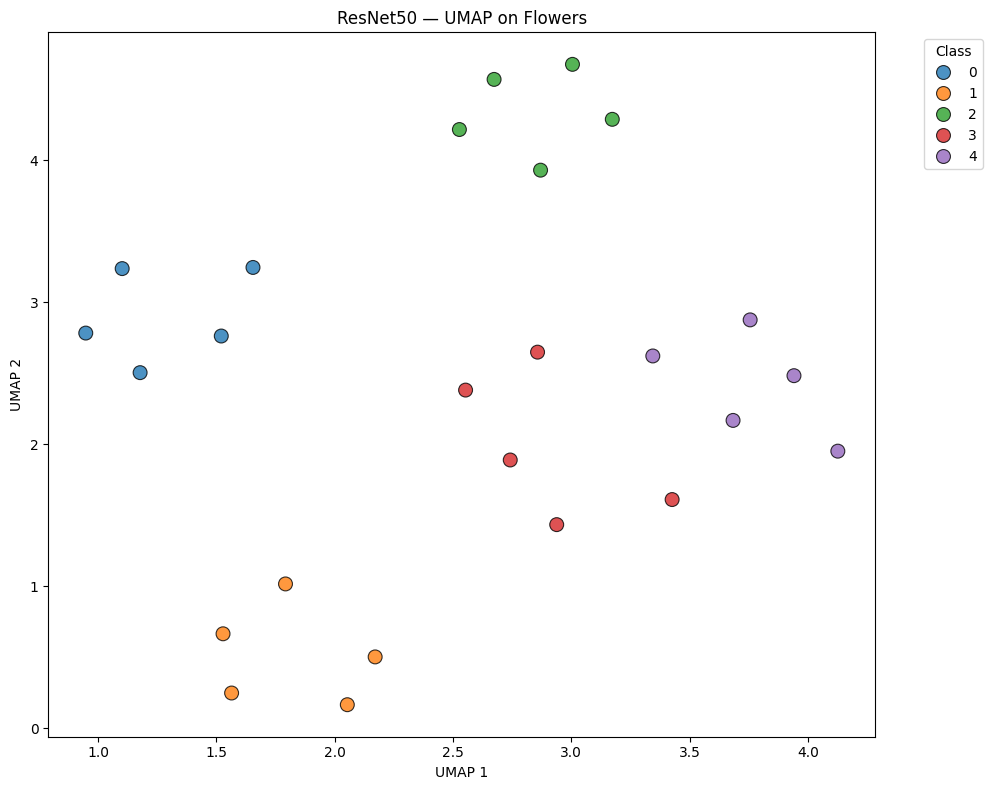

   → Plot saved: ../results/plots/ResNet50_UMAP_flowers.png

Processing InceptionV3...
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step
   → Features extracted: (35, 2048)


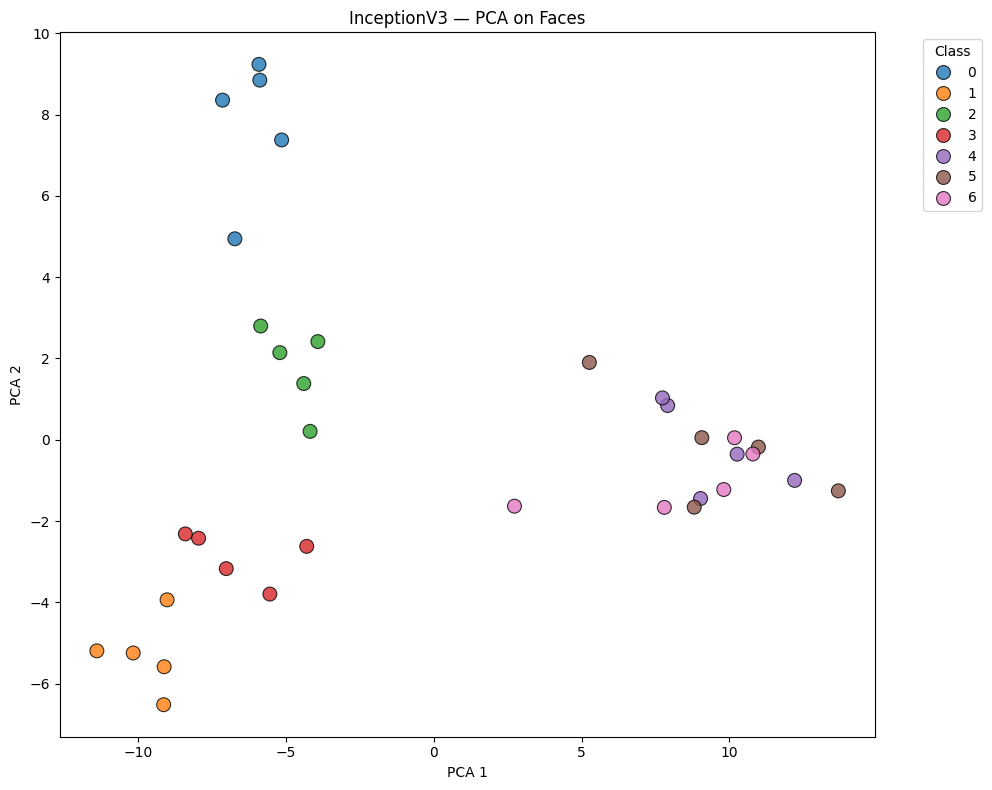

   → Plot saved: ../results/plots/InceptionV3_PCA_faces.png


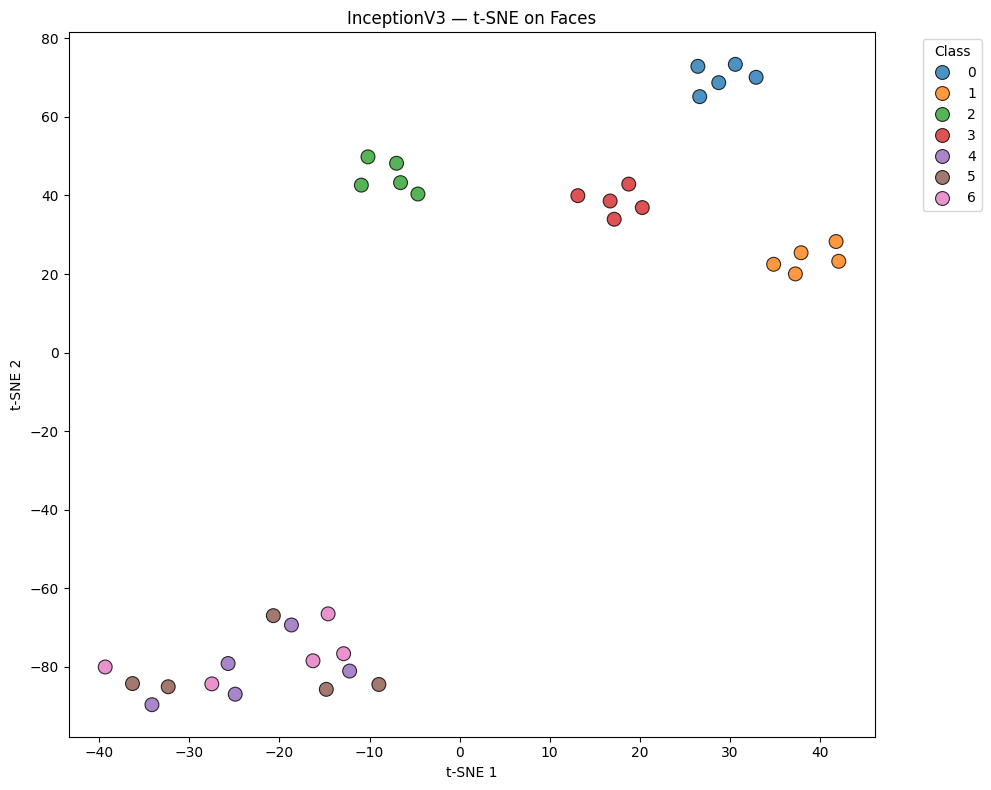

   → Plot saved: ../results/plots/InceptionV3_t-SNE_faces.png


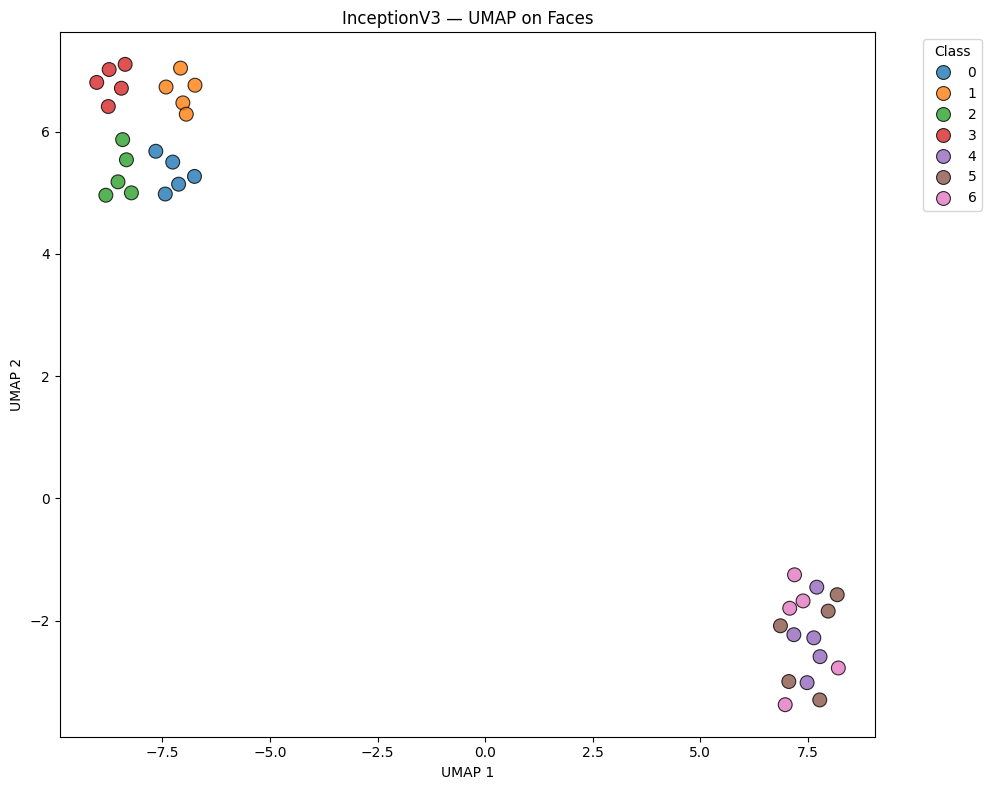

   → Plot saved: ../results/plots/InceptionV3_UMAP_faces.png
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
   → Features extracted: (25, 2048)


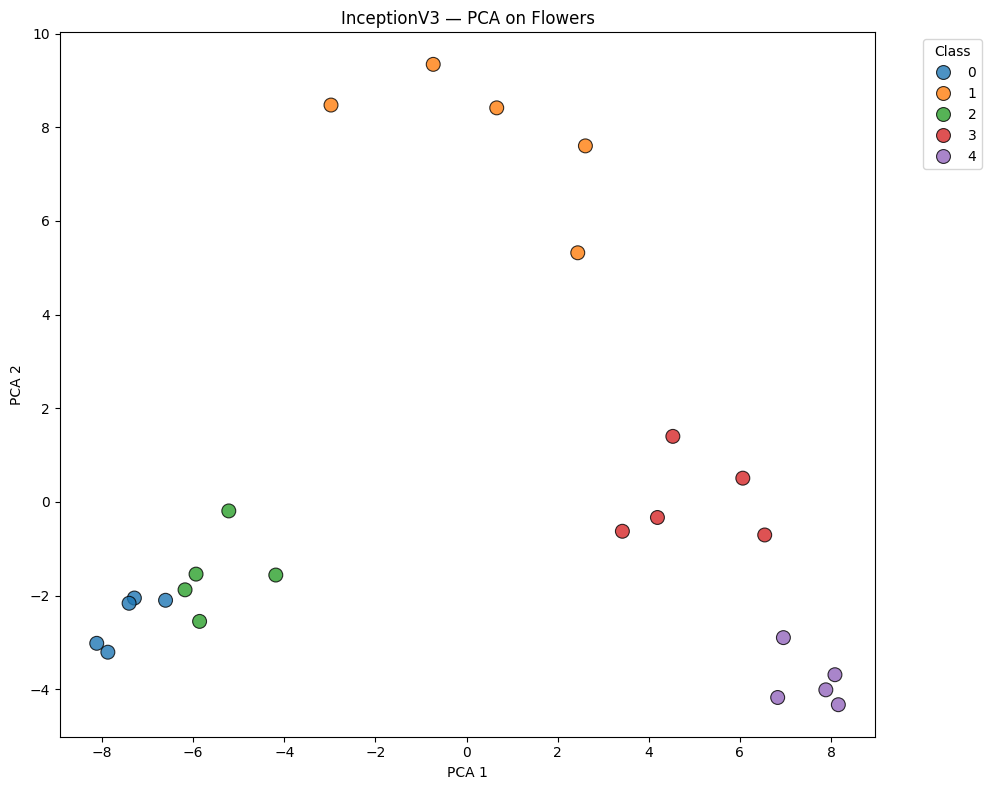

   → Plot saved: ../results/plots/InceptionV3_PCA_flowers.png


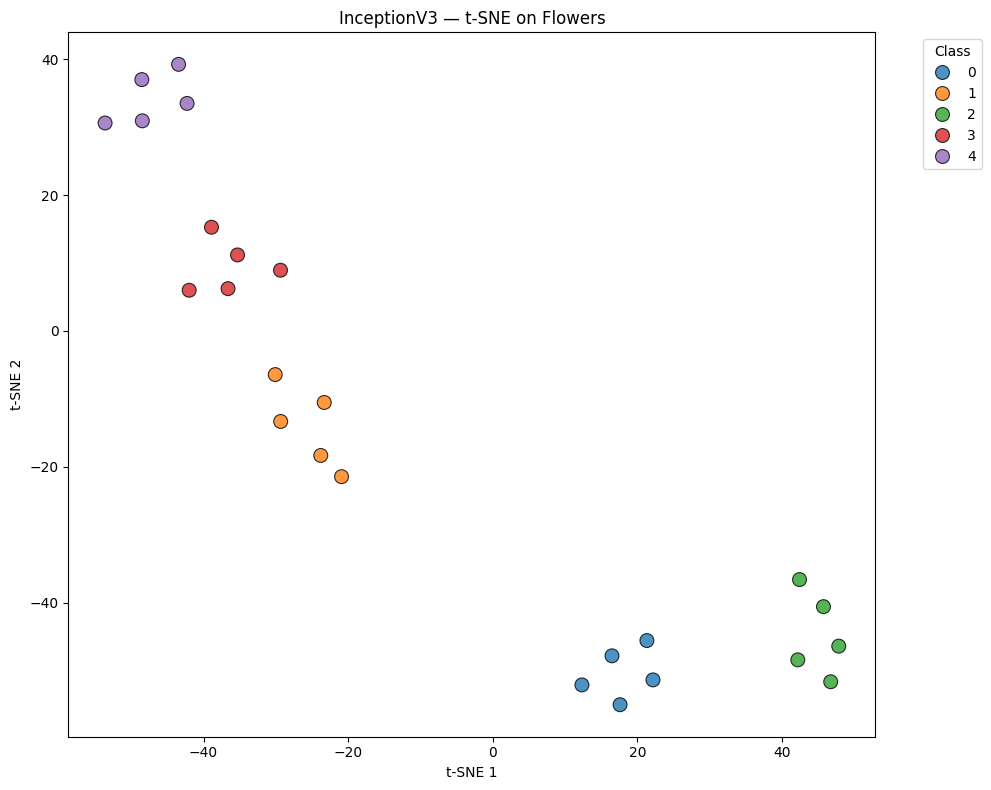

   → Plot saved: ../results/plots/InceptionV3_t-SNE_flowers.png


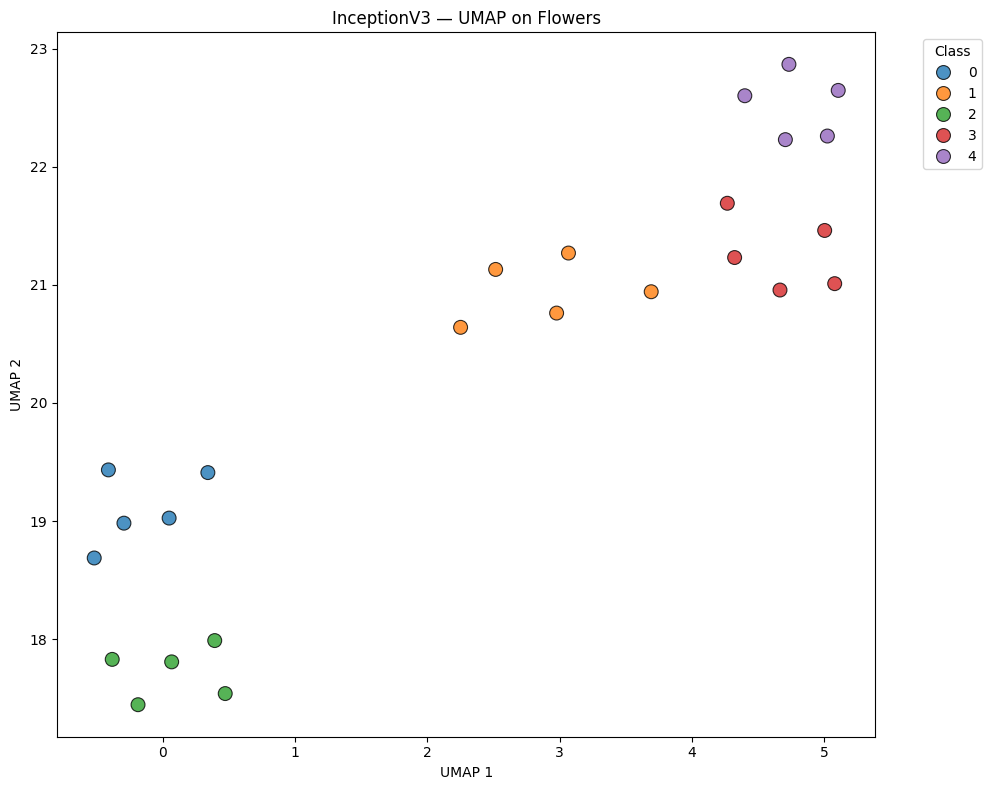

   → Plot saved: ../results/plots/InceptionV3_UMAP_flowers.png

Processing MobileNetV2...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step
   → Features extracted: (35, 1280)


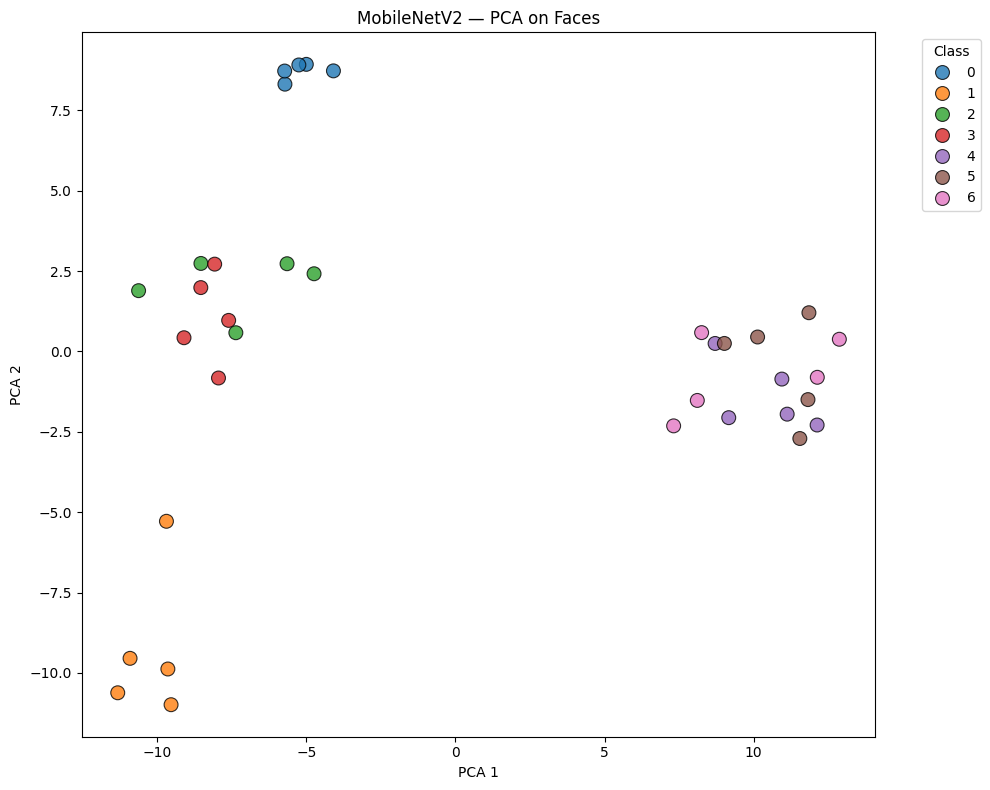

   → Plot saved: ../results/plots/MobileNetV2_PCA_faces.png


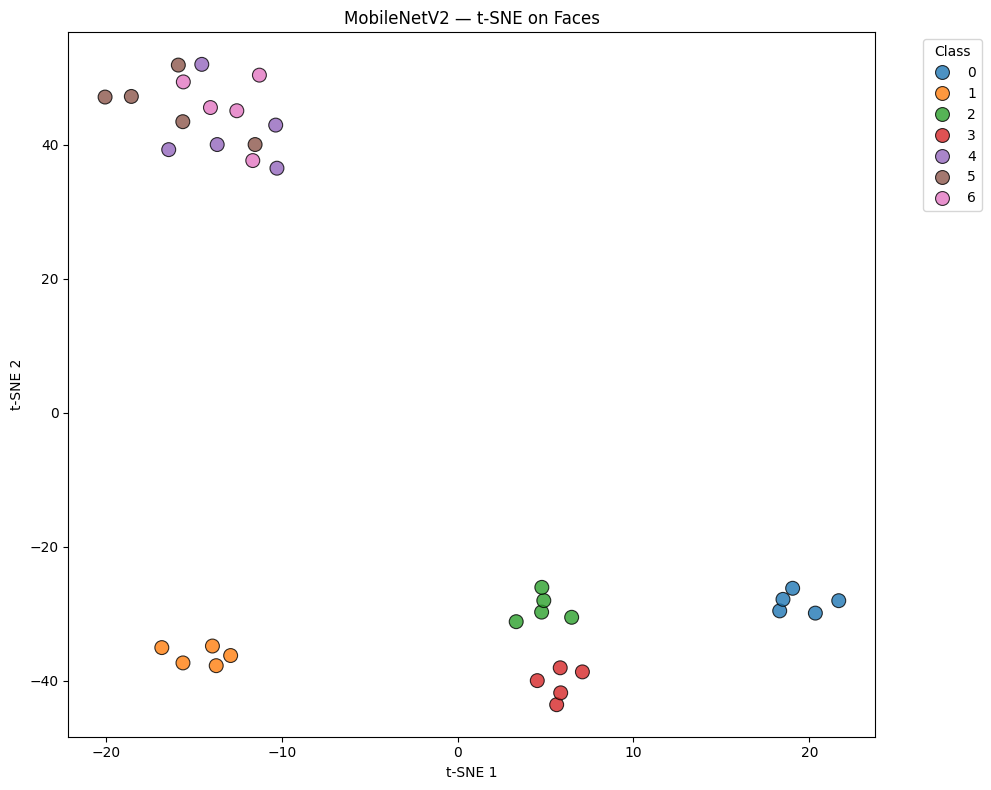

   → Plot saved: ../results/plots/MobileNetV2_t-SNE_faces.png


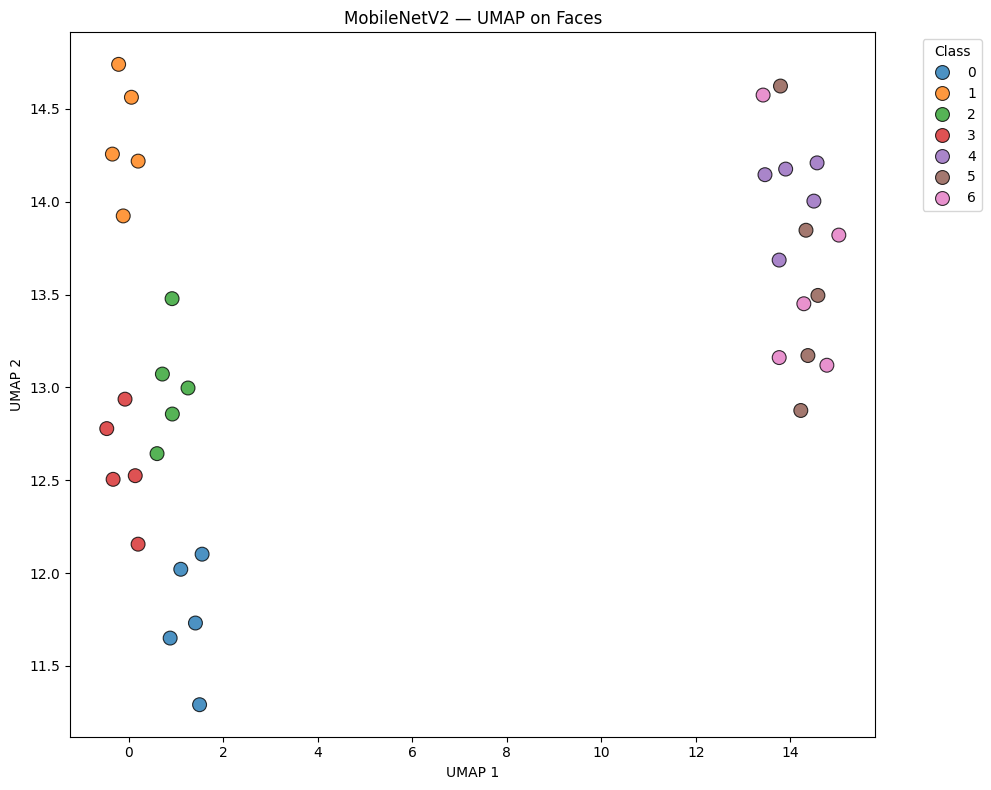

   → Plot saved: ../results/plots/MobileNetV2_UMAP_faces.png
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
   → Features extracted: (25, 1280)


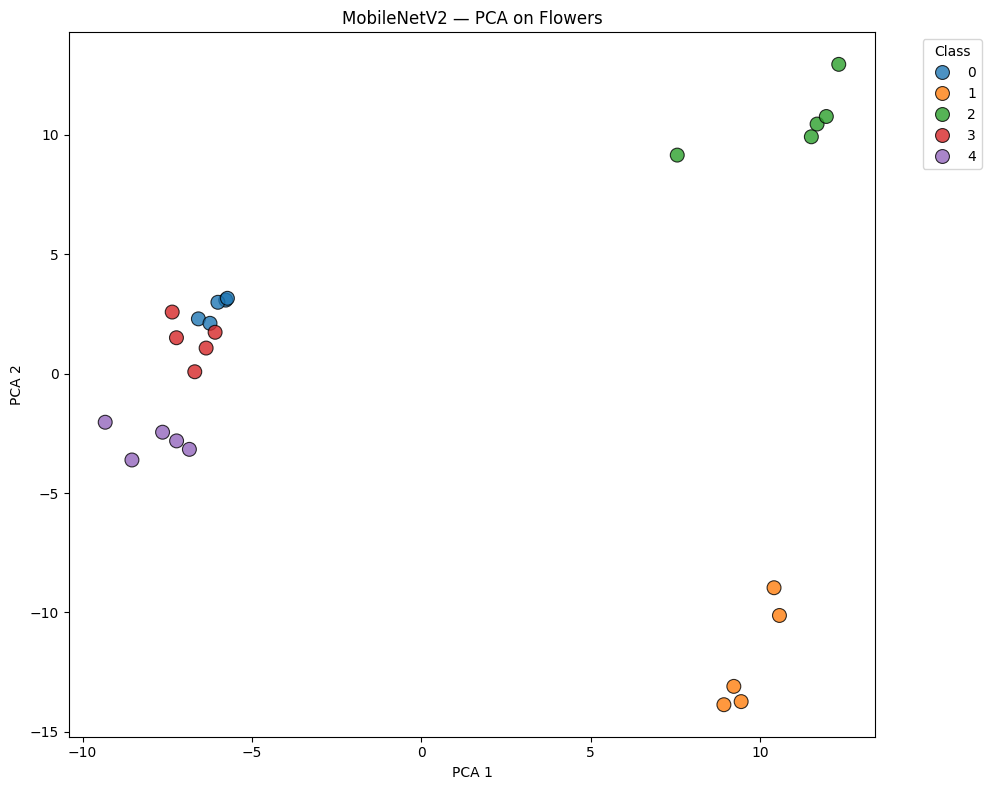

   → Plot saved: ../results/plots/MobileNetV2_PCA_flowers.png


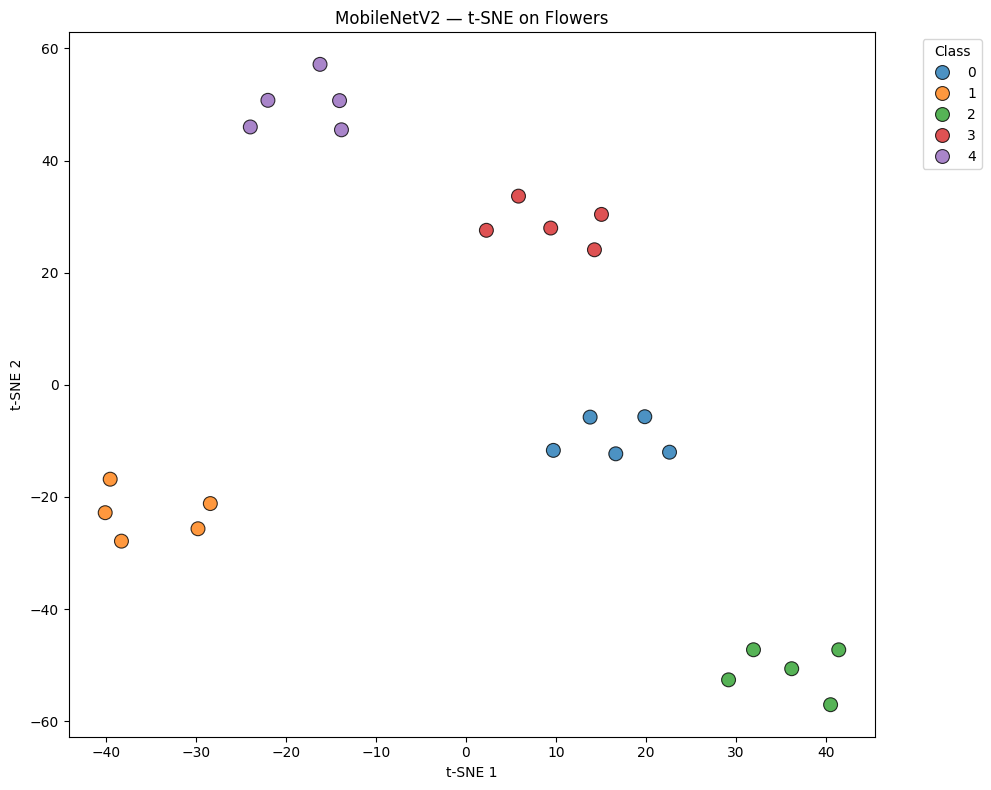

   → Plot saved: ../results/plots/MobileNetV2_t-SNE_flowers.png


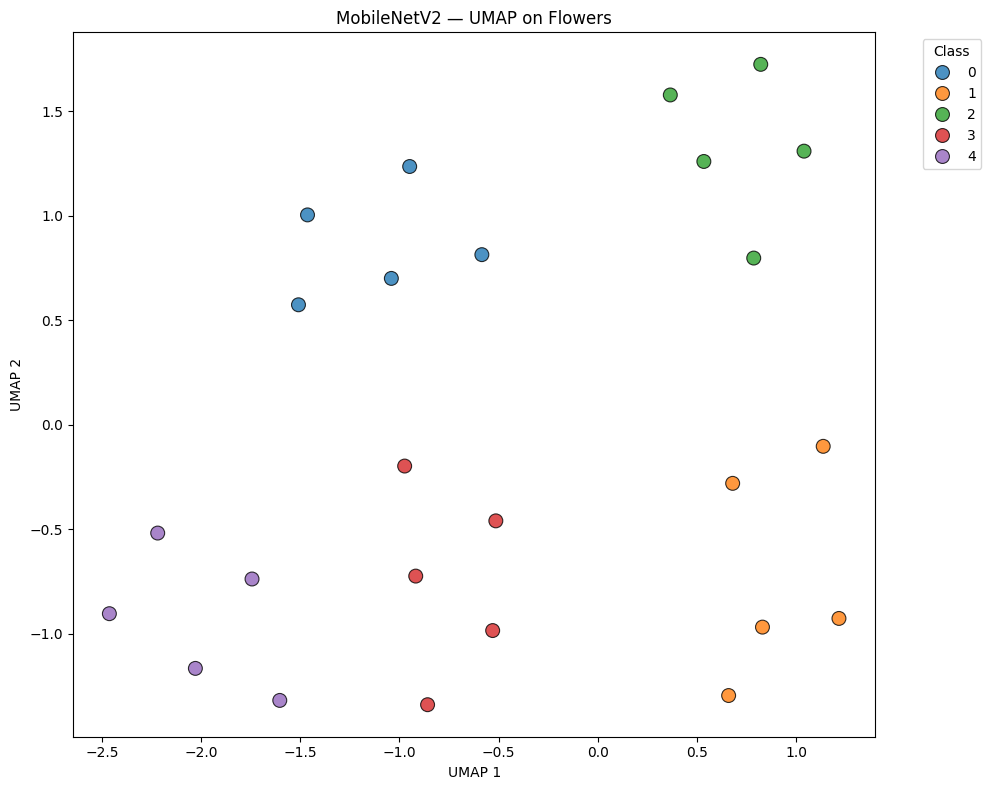

   → Plot saved: ../results/plots/MobileNetV2_UMAP_flowers.png

Processing EfficientNetB0...
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  
   → Features extracted: (35, 1280)


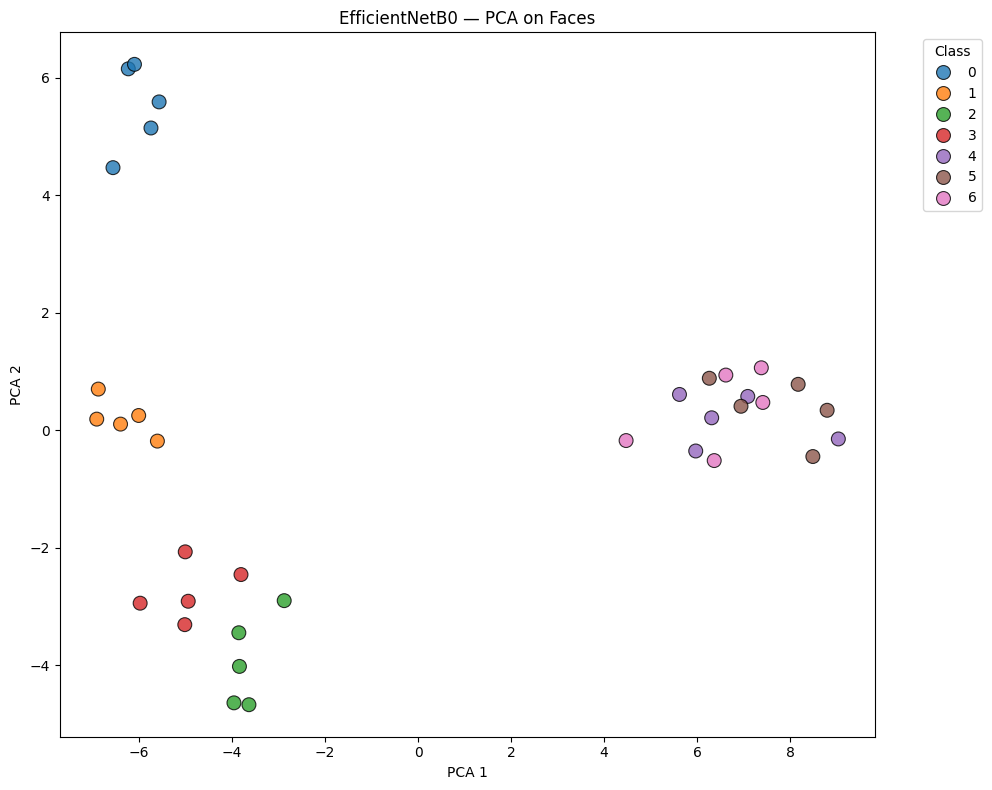

   → Plot saved: ../results/plots/EfficientNetB0_PCA_faces.png


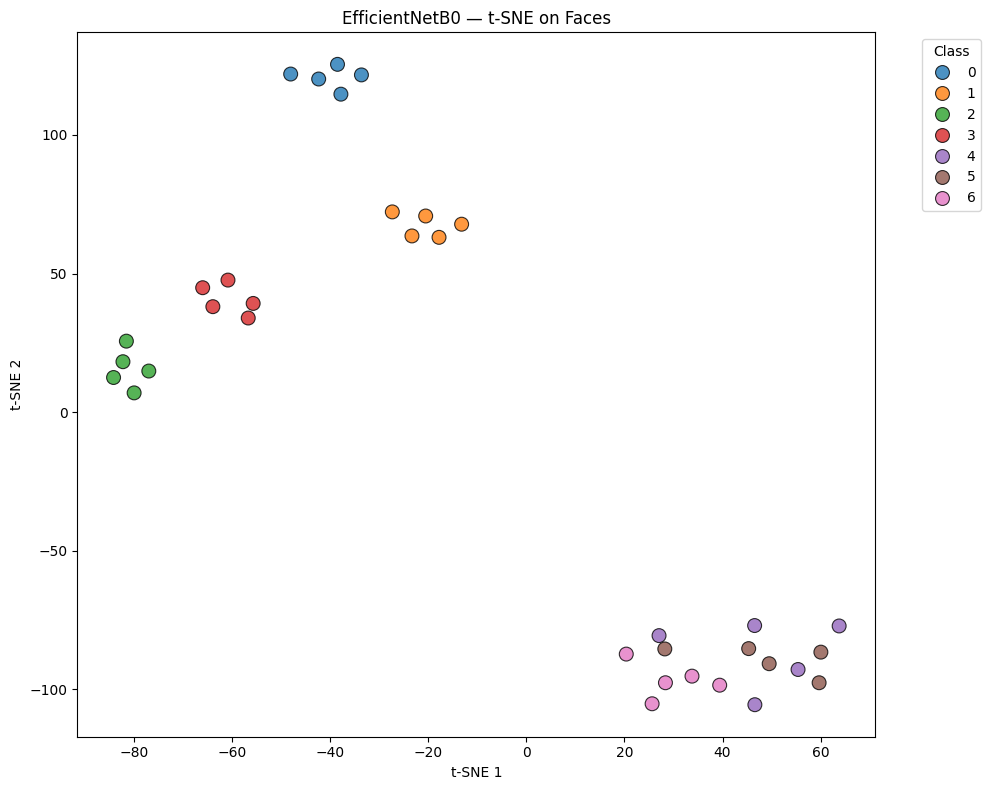

   → Plot saved: ../results/plots/EfficientNetB0_t-SNE_faces.png


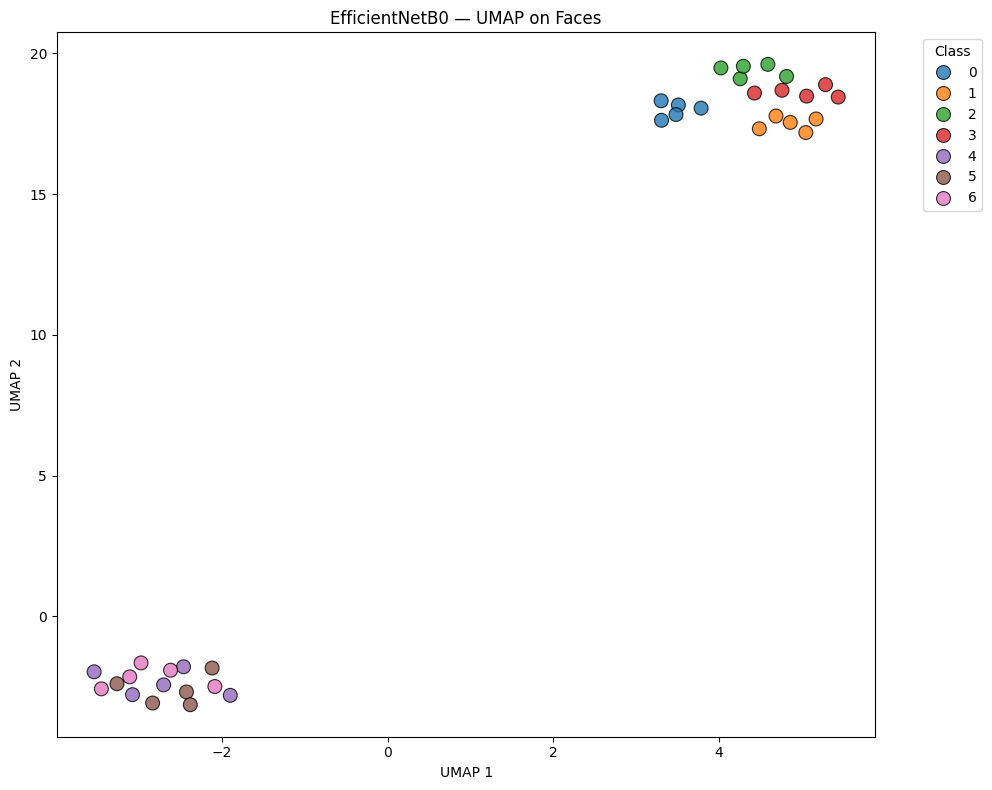

   → Plot saved: ../results/plots/EfficientNetB0_UMAP_faces.png
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
   → Features extracted: (25, 1280)


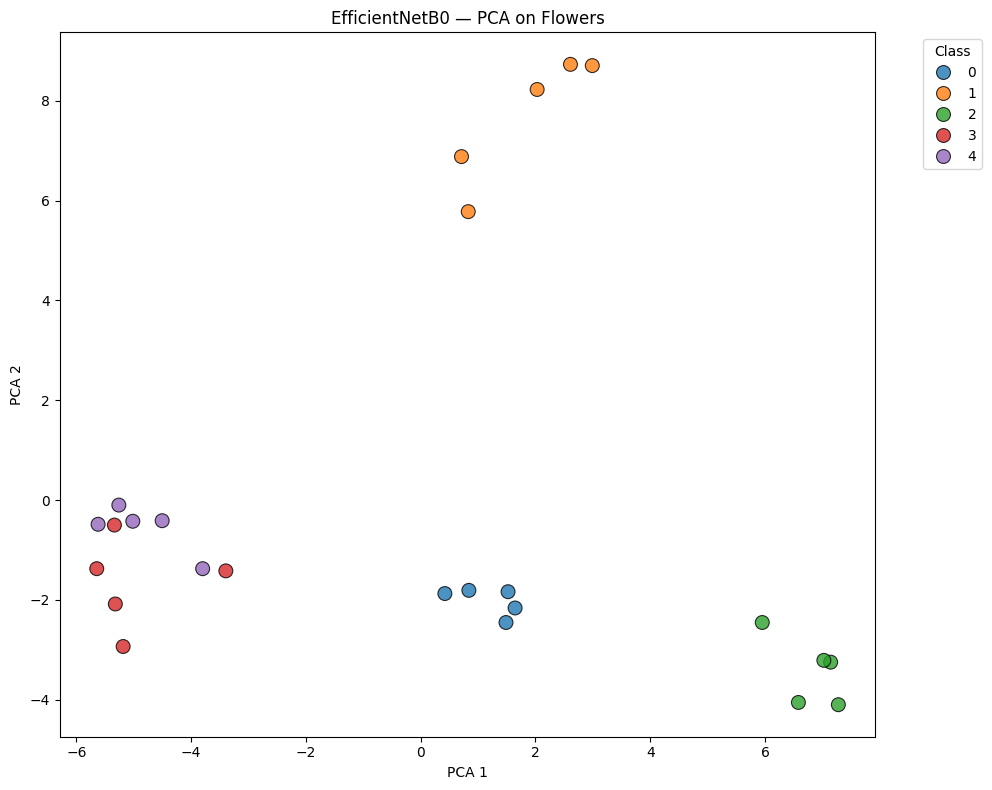

   → Plot saved: ../results/plots/EfficientNetB0_PCA_flowers.png


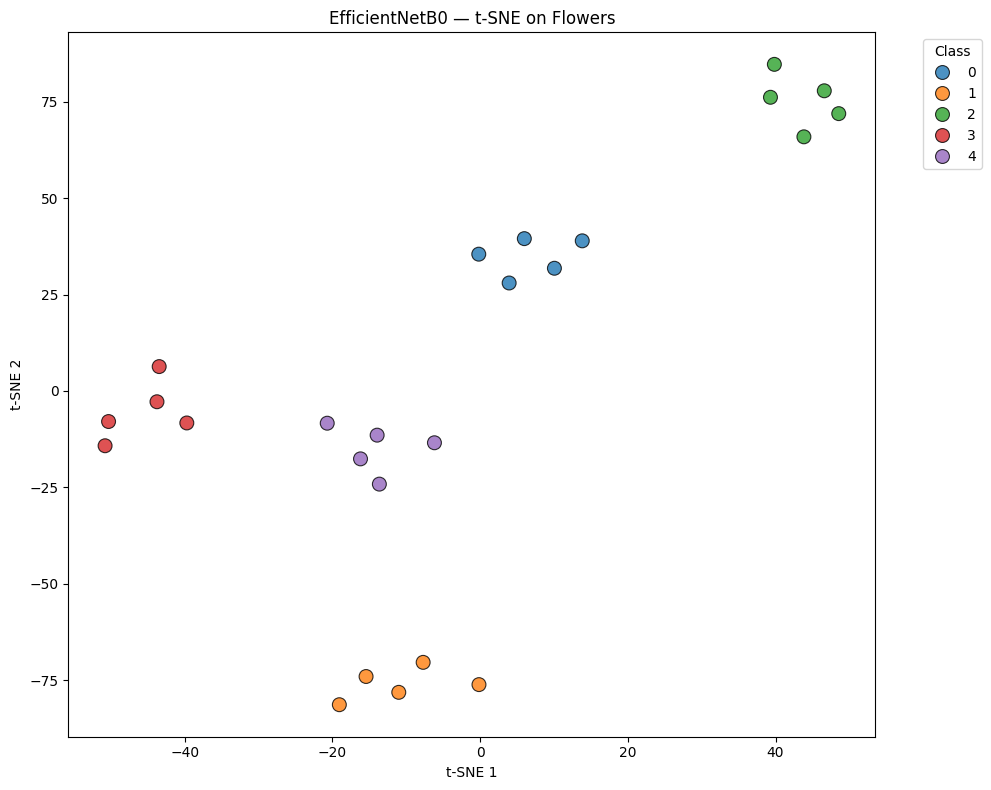

   → Plot saved: ../results/plots/EfficientNetB0_t-SNE_flowers.png


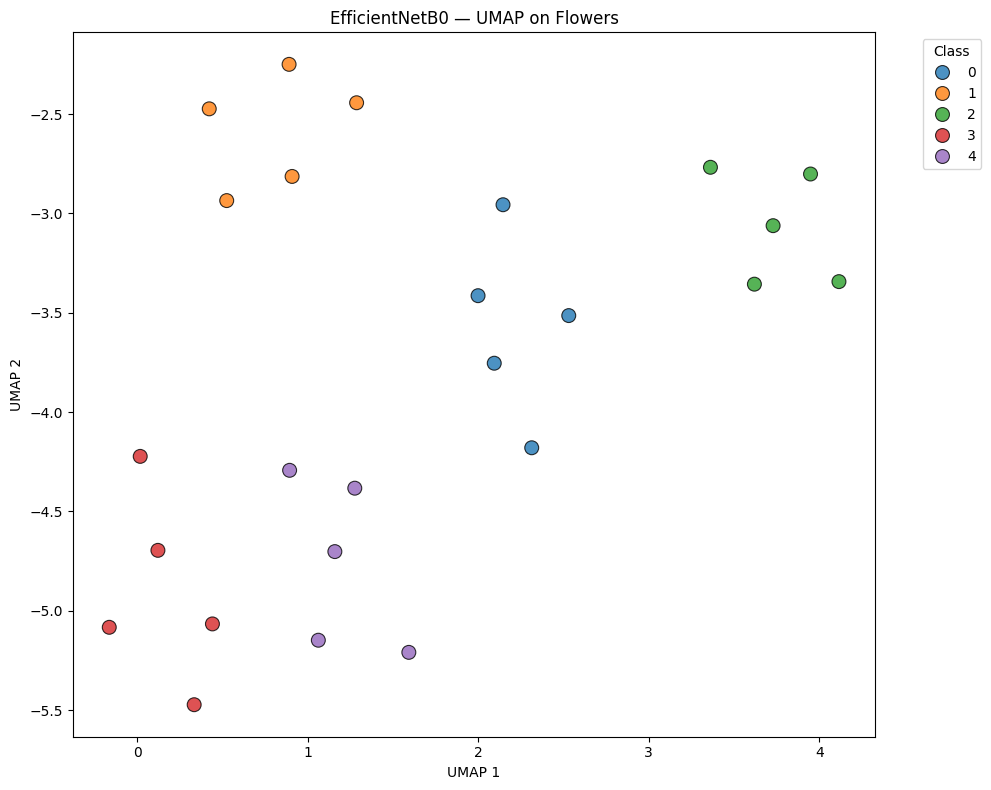

   → Plot saved: ../results/plots/EfficientNetB0_UMAP_flowers.png

Pipeline completed! All plots saved in results/plots/


In [46]:
# ====================== MAIN PIPELINE ======================
print("Starting Assignment Pipeline...")

# 1. Load datasets
face_paths, face_labels, n_faces = load_dataset('../data/faces')
flower_paths, flower_labels, n_flowers = load_dataset('../data/flowers')

print(f"Faces: {len(face_paths)} images, {n_faces} people")
print(f"Flowers: {len(flower_paths)} images, {n_flowers} types\n")

# 2. Classification (Top-1 & Top-5)
face_df = classify_images('../data/faces', "Faces")
flower_df = classify_images('../data/flowers', "Flowers")

# 3. Feature Extraction + Visualization (the core part)
selected_models = ['VGG16', 'ResNet50', 'InceptionV3', 'MobileNetV2', 'EfficientNetB0']
methods = ['PCA', 't-SNE', 'UMAP']

for model_name in selected_models:
    print(f"\nProcessing {model_name}...")
    
    # Faces
    face_features = extract_features(model_name, face_paths)
    for m in methods:
        reduce_and_plot(face_features, face_labels, m, model_name, "Faces")
    
    # Flowers
    flower_features = extract_features(model_name, flower_paths)
    for m in methods:
        reduce_and_plot(flower_features, flower_labels, m, model_name, "Flowers")

print("\nPipeline completed! All plots saved in results/plots/")